# **Import Modules**

In [59]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer 
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.preprocessing import StandardScaler 

from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.tree import DecisionTreeRegressor 

from xgboost import XGBRegressor 
from lightgbm import LGBMRegressor

import optuna


# **Load The Dataset**

In [6]:
train = pd.read_csv('train.csv')

In [8]:
test = pd.read_csv('test.csv')

# **Data Understanding**

In [11]:
train.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524164 entries, 0 to 524163
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         524164 non-null  int64  
 1   RhythmScore                524164 non-null  float64
 2   AudioLoudness              524164 non-null  float64
 3   VocalContent               524164 non-null  float64
 4   AcousticQuality            524164 non-null  float64
 5   InstrumentalScore          524164 non-null  float64
 6   LivePerformanceLikelihood  524164 non-null  float64
 7   MoodScore                  524164 non-null  float64
 8   TrackDurationMs            524164 non-null  float64
 9   Energy                     524164 non-null  float64
 10  BeatsPerMinute             524164 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 44.0 MB


In [17]:
train.isnull().sum()

id                           0
RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
BeatsPerMinute               0
dtype: int64

In [19]:
train.duplicated().sum()

0

In [23]:
train.shape

(524164, 11)

# **EDA**

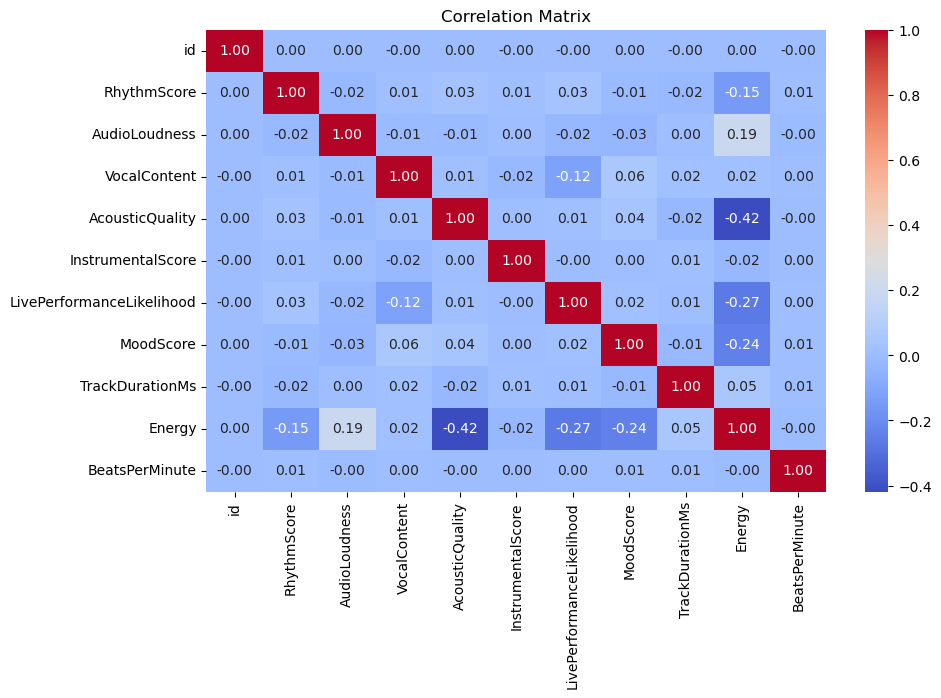

In [28]:
# Heatmap 

plt.figure(figsize=(10, 6))
sns.heatmap(train.corr(), annot= True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

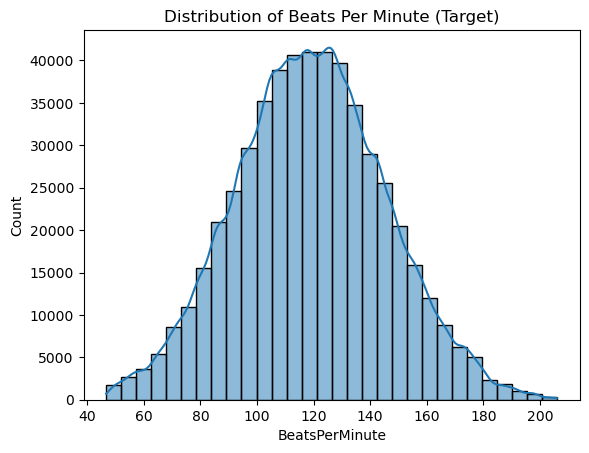

In [32]:
# Quick distribution

sns.histplot(train["BeatsPerMinute"], kde=True, bins=30)
plt.title("Distribution of Beats Per Minute (Target)")
plt.show()

# **Data Preprocessing**

In [35]:
X = train.drop(columns=['id', 'BeatsPerMinute'])
y = train['BeatsPerMinute'] 

X_test_final = test.drop(columns=['id'])

In [41]:
num_columns = X.columns.tolist()

In [47]:
# Pipeline 

numeric_pipe = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, num_columns)
    ]
)

In [49]:
# Train-Test Split 

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
# RMSE scorer for sklearn
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)  # minimize RMSE

# **Optuna Hyperparameter Tuning of All Models - Regressor**

In [ ]:
def objective(trial): 
    model_name = trial.suggest_categorical(
        "model", ["RandomForest", "DecisionTree", "LightGBM", "XGBoost", "Linear"]
    )

    if model_name == "RandomForest":
        n_estimators = trial.suggest_int("rf_n_estimators", 50, 300)
        max_depth = trial.suggest_int("rf_max_depth", 3, 20)
        min_samples_split = trial.suggest_int("rf_min_samples_split", 2, 10)
        
        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42
        )

    elif model_name == "DecisionTree":
        max_depth = trial.suggest_int("dt_max_depth", 3, 20)
        criterion = trial.suggest_categorical("dt_criterion", ["squared_error", "friedman_mse"])
        
        model = DecisionTreeRegressor(
            max_depth=max_depth,
            criterion=criterion,
            random_state=42
        )

    elif model_name == "LightGBM":
        n_estimators = trial.suggest_int("lgb_n_estimators", 100, 300, step=50)
        learning_rate = trial.suggest_float("lgb_learning_rate", 0.01, 0.3)
        num_leaves = trial.suggest_int("lgb_num_leaves", 20, 80)
        
        model = LGBMRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            num_leaves=num_leaves,
            random_state=42
        )

    elif model_name == "XGBoost":
        learning_rate = trial.suggest_float("xgb_learning_rate", 0.01, 0.3, log=True)
        max_depth = trial.suggest_int("xgb_max_depth", 2, 12)
        n_estimators = trial.suggest_int("xgb_n_estimators", 50, 500)
        
        model = XGBRegressor(
            learning_rate=learning_rate,
            max_depth=max_depth,
            n_estimators=n_estimators,
            random_state=42,
            n_jobs=-1
        )

    elif model_name == "Linear":
        model = LinearRegression()

    # Use pipeline with preprocessing
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Cross-validation with RMSE
    scores = cross_val_score(
        pipe, X_train, y_train, cv=3, scoring=rmse_scorer
    )
    return scores.mean()  # Optuna minimizes this


# Random Forest

In [73]:
def objective(trial): 
    model = RandomForestRegressor(
        n_estimators=trial.suggest_int("rf_n_estimators", 50, 300),
        max_depth=trial.suggest_int("rf_max_depth", 3, 20),
        min_samples_split=trial.suggest_int("rf_min_samples_split", 2, 10),
        # min_samples_leaf=trial.suggest_int("rf_min_samples_leaf", 1, 10),
        # bootstrap=trial.suggest_categorical("rf_bootstrap", [True, False]),
        random_state=42
    )

    # Use pipeline with preprocessing
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Cross-validation with RMSE
    scores = cross_val_score(
        pipe, X_train, y_train, cv=3, scoring=rmse_scorer
    )
    return scores.mean()  # Optuna will minimize this


# Decision Tree

In [ ]:
def objective(trial): 
    max_depth = trial.suggest_int("max_depth", 3, 20)
    criterion = trial.suggest_categorical("criterion", ["squared_error", "friedman_mse"])

    model = DecisionTreeRegressor(
        max_depth=max_depth,
        criterion=criterion,
        random_state=42
    )

    # Use pipeline with preprocessing
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Cross-validation with RMSE
    scores = cross_val_score(
        pipe, X_train, y_train, cv=3, scoring=rmse_scorer
    )
    return scores.mean()  # Optuna will minimize this


# LightGBM

In [97]:
def objective(trial): 
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
    num_leaves = trial.suggest_int("num_leaves", 20, 80)

    model = LGBMRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        random_state=42
    )

    # Use pipeline with preprocessing
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Cross-validation with RMSE
    scores = cross_val_score(
        pipe, X_train, y_train, cv=3, scoring=rmse_scorer
    )
    return scores.mean()  # Optuna minimizes this

In [99]:
study = optuna.create_study(direction="minimize")  # minimize RMSE
study.optimize(objective, n_trials=30)

[I 2025-09-14 13:46:59,573] A new study created in memory with name: no-name-2b8ab476-029b-4758-bdba-083925811a34


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008646 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 279554, number of used features: 9
[LightGBM] [Info] Start training from score 119.061496


D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002834 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 279554, number of used features: 9
[LightGBM] [Info] Start training from score 119.056896


D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 279554, number of used features: 9
[LightGBM] [Info] Start training from score 119.056896


D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 279554, number of used features: 9
[LightGBM] [Info] Start training from score 119.051270


D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2025-09-14 13:51:34,696] Trial 29 finished with value: -26.97524558011356 and parameters: {'n_estimators': 354, 'learning_rate': 0.27623924013447915, 'num_leaves': 70}. Best is trial 21 with value: -27.182695437479698.


In [101]:
study.best_params

{'n_estimators': 441, 'learning_rate': 0.29963861999128055, 'num_leaves': 72}

In [103]:
study.best_value

-27.182695437479698

In [105]:
best_model_name = "LightGBM"
best_params = study.best_params.copy()

In [109]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(**best_params, random_state=42))
])


In [111]:
best_model.fit(X, y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016851 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 524164, number of used features: 9
[LightGBM] [Info] Start training from score 119.034899


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [113]:
preds = best_model.predict(X_test_final) 

D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [115]:
submission = pd.DataFrame({
    "id": test["id"],
    "BeatsPerMinute": preds
})
submission.to_csv("submission2.csv", index=False)
print("✅ submission.csv saved with Optuna-tuned model!")

✅ submission.csv saved with Optuna-tuned model!


# XGBoost

In [77]:
def objective(trial): 
    # Hyperparameter suggestions
    learning_rate = trial.suggest_float("xgb_learning_rate", 0.01, 0.3, log=True)
    max_depth = trial.suggest_int("xgb_max_depth", 2, 12)
    n_estimators = trial.suggest_int("xgb_n_estimators", 50, 500)

    # Model with suggested params
    model = XGBRegressor(
        learning_rate=learning_rate,
        max_depth=max_depth,
        n_estimators=n_estimators,
        random_state=42,
        n_jobs=-1
    )

    # Use pipeline with preprocessing
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Cross-validation with RMSE
    scores = cross_val_score(
        pipe, X_train, y_train, cv=3, scoring=rmse_scorer
    )
    return scores.mean()  # Optuna will minimize this


In [79]:
study = optuna.create_study(direction="minimize")  # minimize RMSE
study.optimize(objective, n_trials=30)

[I 2025-09-14 13:06:06,901] A new study created in memory with name: no-name-ce0e92e6-5f43-4269-ae34-4a25970a494c
[I 2025-09-14 13:06:40,939] Trial 0 finished with value: -26.566196705915427 and parameters: {'xgb_learning_rate': 0.033808333214027576, 'xgb_max_depth': 9, 'xgb_n_estimators': 347}. Best is trial 0 with value: -26.566196705915427.
[I 2025-09-14 13:07:04,762] Trial 1 finished with value: -26.69693690908777 and parameters: {'xgb_learning_rate': 0.09005248613655331, 'xgb_max_depth': 11, 'xgb_n_estimators': 118}. Best is trial 1 with value: -26.69693690908777.
[I 2025-09-14 13:07:15,063] Trial 2 finished with value: -26.491830535203388 and parameters: {'xgb_learning_rate': 0.13634329327083508, 'xgb_max_depth': 3, 'xgb_n_estimators': 467}. Best is trial 1 with value: -26.69693690908777.
[I 2025-09-14 13:07:22,747] Trial 3 finished with value: -26.481831990329862 and parameters: {'xgb_learning_rate': 0.13046184152223111, 'xgb_max_depth': 3, 'xgb_n_estimators': 314}. Best is tria

In [81]:
study.best_params

{'xgb_learning_rate': 0.2977992278474562,
 'xgb_max_depth': 12,
 'xgb_n_estimators': 495}

In [83]:
study.best_value

-28.865947090215087

In [87]:
best_model_name = "XGBoost"
best_params = study.best_params.copy()

In [89]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(**best_params, random_state=42))
])


In [91]:
best_model.fit(X, y)

D:\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:40:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "xgb_learning_rate", "xgb_max_depth", "xgb_n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [93]:
preds = best_model.predict(X_test_final)

In [95]:
submission = pd.DataFrame({
    "id": test["id"],
    "BeatsPerMinute": preds
})
submission.to_csv("submission.csv", index=False)
print("✅ submission.csv saved with Optuna-tuned model!")

✅ submission.csv saved with Optuna-tuned model!
